# Global Trading Strategy Tuning

This notebook tunes a shared probability-based trading strategy using validation-period prediction files from all model families. The purpose is to choose one common set of trading parameters that can be applied consistently across Gradient Boosting, ELM, GRU, and FAVAR models.

The strategy takes each model's predicted probability of an upward WTI move and converts it into a daily trading position. Positions are volatility-scaled, clipped to a maximum absolute exposure, and evaluated after transaction costs. Tuning is performed on validation predictions only so the final test period remains held out.

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid

## 1. Define the Probability/Volatility Trading Strategy

This function converts predicted up-move probabilities into daily trading positions. Probabilities above the long threshold create positive exposure, while probabilities below the short threshold create negative exposure. The signal is then adjusted using asymmetric long/short scaling, nonlinear signal shaping, volatility targeting, position clipping, and transaction costs.

Strategy returns are calculated using the previous day's position multiplied by the current day's realized return. This avoids look-ahead bias because the strategy does not earn today's return using a position chosen after observing that return.

In [ ]:
def apply_probability_vol_strategy_tuned(
    preds,
    signal_multiplier=2.5,
    long_threshold=0.50,
    short_threshold=0.50,
    target_annual_vol=0.15,
    vol_col="vol_20",
    transaction_cost=0.0005,
    vol_floor=0.005,
    alpha=1.0,
    beta=1.0,
    gamma=1.0,
    max_position=1.0
):
    df = preds.copy()

    prob = df["prob_up"]

    # Initialize the raw trading signal.
    # Positive values will represent long exposure, negative values short exposure,
    # and zero means no position.
    raw_signal = np.zeros(len(df))

    # Identify days where the model probability is strong enough to justify
    # a long or short signal.
    long_mask = prob >= long_threshold
    short_mask = prob <= short_threshold

    # Convert predicted probabilities into raw directional signals.
    # If prob_up is above the long threshold, the signal is positive.
    # If prob_up is below the short threshold, the signal is negative because
    # prob - short_threshold is less than zero.
    raw_signal[long_mask] = signal_multiplier * (prob[long_mask] - long_threshold)
    raw_signal[short_mask] = signal_multiplier * (prob[short_mask] - short_threshold)

    # Apply asymmetric scaling to long and short signals.
    # alpha controls the aggressiveness of long positions.
    # beta controls the aggressiveness of short positions.
    raw_signal = np.where(
        raw_signal >= 0,
        alpha * raw_signal,
        beta * raw_signal
    )

    # Apply nonlinear confidence scaling.
    # gamma controls how strongly the strategy responds to probability deviations.
    # If gamma < 1, modest signals are amplified.
    # If gamma > 1, modest signals are compressed.
    raw_signal = np.sign(raw_signal) * (np.abs(raw_signal) ** gamma)

    # Convert the annual volatility target into a daily volatility target.
    # This is used to scale positions so the strategy takes less exposure
    # when recent realized volatility is high.
    target_daily_vol = target_annual_vol / np.sqrt(252)

    # Use recent realized volatility for volatility targeting.
    # The volatility floor prevents extremely large positions when volatility is very low.
    adjusted_vol = df[vol_col].clip(lower=vol_floor)
    
    # Scale the probability-based signal by the volatility target.
    # Higher realized volatility reduces position size, while lower realized volatility
    # allows larger position size, subject to the max_position cap.
    df["position"] = raw_signal * (target_daily_vol / adjusted_vol)

    # Cap exposure so the strategy cannot exceed the maximum long or short position.
    df["position"] = df["position"].clip(-max_position, max_position)

    # Calculate daily turnover as the absolute change in position.
    # This is used to penalize frequent trading through transaction costs.
    df["turnover"] = (df["position"] - df["position"].shift(1)).abs()

    # Calculate gross strategy returns using the previous day's position.
    # The lag is important because the strategy should only earn returns on positions
    # that were known before the current day's return occurred.
    df["gross_strategy_return"] = df["position"].shift(1) * df["returns"]

    # Subtract transaction costs based on daily turnover.
    # This gives a more realistic net return series than ignoring trading frictions.
    df["net_strategy_return"] = (
        df["gross_strategy_return"] - transaction_cost * df["turnover"]
    )

    # Store buy-and-hold returns for comparison against the model-based strategy.
    df["buy_hold_return"] = df["returns"]

    return df

## 2. List Validation Prediction Files

The strategy is tuned using validation predictions from every model family and model version. This includes pre-COT baselines, COT-augmented baselines, regime-feature models, and regime-specific models for Gradient Boosting, ELM, GRU, and FAVAR.

Using all validation prediction files encourages the selected strategy parameters to be general rather than optimized for only one model.

In [3]:
prediction_files = [
    "results/predictions/gb_pre_cot_baseline_val_predictions.csv",
    "results/predictions/gb_baseline_val_predictions.csv",
    "results/predictions/gb_regime_feature_val_predictions.csv",
    "results/predictions/gb_regime_specific_val_predictions.csv",

    "results/predictions/elm_pre_cot_baseline_val_predictions.csv",
    "results/predictions/elm_baseline_val_predictions.csv",
    "results/predictions/elm_regime_feature_val_predictions.csv",
    "results/predictions/elm_regime_specific_val_predictions.csv",

    "results/predictions/gru_pre_cot_baseline_val_predictions.csv",
    "results/predictions/gru_baseline_val_predictions.csv",
    "results/predictions/gru_regime_feature_val_predictions.csv",
    "results/predictions/gru_regime_specific_val_predictions.csv",

    "results/predictions/favar_pre_cot_baseline_val_predictions.csv",
    "results/predictions/favar_baseline_val_predictions.csv",
    "results/predictions/favar_regime_feature_val_predictions.csv",
    "results/predictions/favar_regime_specific_val_predictions.csv",
]

## 3. Load Validation Predictions

Each prediction file is loaded into a dataframe and tagged with its source file. The model and version columns are preserved when available, or inferred from the file name if missing. These dataframes are then stored in a list so the same strategy grid can be evaluated across all model outputs.

In [4]:
val_pred_dfs = []

for file in prediction_files:
    df = pd.read_csv(file)
    df["Date"] = pd.to_datetime(df["Date"])

    if "model" not in df.columns:
        df["model"] = file.split("/")[-1].split("_")[0]

    if "version" not in df.columns:
        df["version"] = file.split("/")[-1].replace("_val_predictions.csv", "")

    df["source_file"] = file

    val_pred_dfs.append(df)

print("Loaded files:", len(val_pred_dfs))

Loaded files: 16


## 4. Define the Strategy Parameter Grid

The grid searches over signal strength, long/short scaling, nonlinear signal shaping, and target volatility. The long and short probability thresholds are fixed at 0.50 because earlier exploration showed that 0.50 was most stable across models. Keeping the thresholds fixed also reduces the chance of overfitting the trading rule to validation noise.

In [ ]:
strategy_grid = {
    "signal_multiplier": [2.5, 3.0, 3.5, 4.0, 4.5, 5.0],
    # freezing thesholds, tuning showed 0.50 was the best across most models and all the best ones
    "long_threshold": [0.50],
    "short_threshold": [0.50],
    # < 1 wasn't good
    "alpha": [1.0, 1.25, 1.5, 2.0, 2.25, 2.5, 2.75, 3.0, 3.5],
    "beta": [1.0, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5, 1.55, 1.60, 1.65, 1.70, 1.75],
    # > 1 was bad
    "gamma": [0.4, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.9],
    "target_annual_vol": [0.20, 0.22, 0.24, 0.26, 0.28, 0.30, 0.32, 0.34, 0.35]
}

strategy_param_list = list(ParameterGrid(strategy_grid))

print("Total strategy combinations:", len(strategy_param_list))

Total strategy combinations: 64152


## 5. Define Strategy Performance Metrics

This helper computes the trading metrics used to rank strategy parameter combinations. Total return and CAGR measure growth, annualized volatility measures risk, Sharpe ratio measures risk-adjusted performance, maximum drawdown captures downside risk, and average turnover approximates trading activity.

In [34]:
def strategy_metrics(df, return_col, periods_per_year=252):
    data = df.dropna(subset=[return_col]).copy()

    ret = data[return_col]

    total_return = (1 + ret).prod() - 1
    n_years = len(ret) / periods_per_year

    cagr = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else np.nan

    ann_vol = ret.std() * np.sqrt(periods_per_year)
    ann_return = ret.mean() * periods_per_year

    sharpe = ann_return / ann_vol if ann_vol != 0 else np.nan

    wealth = (1 + ret).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    max_drawdown = drawdown.min()

    avg_position = data["position"].mean() if "position" in data.columns else np.nan
    avg_abs_position = data["position"].abs().mean() if "position" in data.columns else np.nan
    avg_turnover = data["turnover"].mean() if "turnover" in data.columns else np.nan

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annual Return": ann_return,
        "Annual Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown,
        "Avg Position": avg_position,
        "Avg Abs Position": avg_abs_position,
        "Avg Turnover": avg_turnover
    }

## 6. Evaluate the Strategy Grid Across All Validation Predictions

For each strategy parameter combination, I apply the trading rule to every validation prediction file. I then summarize performance across models using average Sharpe, median Sharpe, average total return, average drawdown, worst drawdown, average turnover, and average absolute position.

This creates a global strategy selection criterion. The selected parameters are not optimized for a single model; they are chosen based on average validation performance across the full model set.

In [ ]:
strategy_results = []

# Evaluate every strategy parameter combination across all validation prediction files.
for combo_num, params in enumerate(strategy_param_list, start=1):
    model_level_results = []

    for preds in val_pred_dfs:
        strategy_df = apply_probability_vol_strategy_tuned(
            preds,
            signal_multiplier=params["signal_multiplier"],
            long_threshold=params["long_threshold"],
            short_threshold=params["short_threshold"],
            alpha=params["alpha"],
            beta=params["beta"],
            gamma=params["gamma"],
            target_annual_vol=params["target_annual_vol"]
        )

        metrics = strategy_metrics(strategy_df, "net_strategy_return")

        model_level_results.append({
            "model": preds["model"].iloc[0],
            "version": preds["version"].iloc[0],
            "source_file": preds["source_file"].iloc[0],
            "Total Return": metrics["Total Return"],
            "CAGR": metrics["CAGR"],
            "Annual Vol": metrics["Annual Vol"],
            "Sharpe": metrics["Sharpe"],
            "Max Drawdown": metrics["Max Drawdown"],
            "Avg Position": metrics["Avg Position"],
            "Avg Abs Position": metrics["Avg Abs Position"],
            "Avg Turnover": metrics["Avg Turnover"]
        })

    model_results_df = pd.DataFrame(model_level_results)

    avg_sharpe = model_results_df["Sharpe"].mean()
    median_sharpe = model_results_df["Sharpe"].median()
    avg_return = model_results_df["Total Return"].mean()
    avg_drawdown = model_results_df["Max Drawdown"].mean()
    worst_drawdown = model_results_df["Max Drawdown"].min()
    avg_turnover = model_results_df["Avg Turnover"].mean()
    avg_abs_position = model_results_df["Avg Abs Position"].mean()

    strategy_results.append({
        **params,
        "avg_sharpe": avg_sharpe,
        "median_sharpe": median_sharpe,
        "avg_total_return": avg_return,
        "avg_max_drawdown": avg_drawdown,
        "worst_max_drawdown": worst_drawdown,
        "avg_turnover": avg_turnover,
        "avg_abs_position": avg_abs_position
    })

strategy_results_df = pd.DataFrame(strategy_results)

## 7. Rank Strategy Parameter Combinations

The strategy combinations are ranked by average validation Sharpe and then by average total return. This prioritizes risk-adjusted performance while still using total return as a secondary tie-breaker.

In [36]:
strategy_results_ranked = strategy_results_df.sort_values(
    by=["avg_sharpe", "avg_total_return"],
    ascending=False
).reset_index(drop=True)

strategy_results_ranked.head(20)

,alpha,beta,gamma,long_threshold,short_threshold,signal_multiplier,target_annual_vol,avg_sharpe,median_sharpe,avg_total_return,avg_max_drawdown,worst_max_drawdown,avg_turnover,avg_abs_position
0,3.00,1.55,0.70,0.5,0.5,3.5,0.28,0.819483,0.528290,0.239285,-0.227772,-0.464235,0.103453,0.456984
1,2.50,1.30,0.70,0.5,0.5,3.0,0.35,0.819466,0.532965,0.237125,-0.226465,-0.464959,0.102701,0.453778
2,2.50,1.35,0.70,0.5,0.5,3.0,0.35,0.819460,0.531382,0.240074,-0.227134,-0.464166,0.103716,0.456577
3,3.00,1.60,0.70,0.5,0.5,3.5,0.28,0.819458,0.526921,0.241779,-0.228340,-0.463564,0.104310,0.459342
4,3.00,1.45,0.65,0.5,0.5,3.0,0.32,0.819457,0.510396,0.254484,-0.233000,-0.462517,0.107833,0.475281
5,3.00,1.55,0.70,0.5,0.5,2.5,0.35,0.819454,0.533277,0.236621,-0.226354,-0.465092,0.102531,0.453303
6,3.50,1.70,0.65,0.5,0.5,4.0,0.24,0.819450,0.510379,0.254757,-0.233029,-0.462462,0.107922,0.475490
7,3.00,1.60,0.70,0.5,0.5,2.5,0.35,0.819441,0.531855,0.239074,-0.226915,-0.464429,0.103381,0.455654
8,2.50,1.30,0.70,0.5,0.5,3.5,0.32,0.819437,0.525740,0.241034,-0.228583,-0.463773,0.104073,0.459225
9,2.75,1.35,0.65,0.5,0.5,4.0,0.28,0.819427,0.510816,0.254976,-0.232907,-0.462465,0.107992,0.475456


## 8. Select the Candidate Strategy Set

The final selection uses all grid-search results ranked by validation performance. 

In [ ]:
filtered_strategy_results = strategy_results_df.copy()


filtered_strategy_results = filtered_strategy_results.sort_values(
    by=["avg_sharpe", "avg_total_return"],
    ascending=False
).reset_index(drop=True)

filtered_strategy_results.head(20)

,alpha,beta,gamma,long_threshold,short_threshold,signal_multiplier,target_annual_vol,avg_sharpe,median_sharpe,avg_total_return,avg_max_drawdown,worst_max_drawdown,avg_turnover,avg_abs_position
0,3.00,1.55,0.70,0.5,0.5,3.5,0.28,0.819483,0.528290,0.239285,-0.227772,-0.464235,0.103453,0.456984
1,2.50,1.30,0.70,0.5,0.5,3.0,0.35,0.819466,0.532965,0.237125,-0.226465,-0.464959,0.102701,0.453778
2,2.50,1.35,0.70,0.5,0.5,3.0,0.35,0.819460,0.531382,0.240074,-0.227134,-0.464166,0.103716,0.456577
3,3.00,1.60,0.70,0.5,0.5,3.5,0.28,0.819458,0.526921,0.241779,-0.228340,-0.463564,0.104310,0.459342
4,3.00,1.45,0.65,0.5,0.5,3.0,0.32,0.819457,0.510396,0.254484,-0.233000,-0.462517,0.107833,0.475281
5,3.00,1.55,0.70,0.5,0.5,2.5,0.35,0.819454,0.533277,0.236621,-0.226354,-0.465092,0.102531,0.453303
6,3.50,1.70,0.65,0.5,0.5,4.0,0.24,0.819450,0.510379,0.254757,-0.233029,-0.462462,0.107922,0.475490
7,3.00,1.60,0.70,0.5,0.5,2.5,0.35,0.819441,0.531855,0.239074,-0.226915,-0.464429,0.103381,0.455654
8,2.50,1.30,0.70,0.5,0.5,3.5,0.32,0.819437,0.525740,0.241034,-0.228583,-0.463773,0.104073,0.459225
9,2.75,1.35,0.65,0.5,0.5,4.0,0.28,0.819427,0.510816,0.254976,-0.232907,-0.462465,0.107992,0.475456


## 9. Extract the Best Validation Strategy Parameters

The top-ranked row becomes the selected strategy parameter set. These values are later saved and reused in the final test evaluation notebooks.

In [88]:
best_strategy_params = filtered_strategy_results.iloc[0].to_dict()

best_strategy_params

{'alpha': 3.0,
 'beta': 1.55,
 'gamma': 0.7,
 'long_threshold': 0.5,
 'short_threshold': 0.5,
 'signal_multiplier': 3.5,
 'target_annual_vol': 0.28,
 'avg_sharpe': 0.8194827845409737,
 'median_sharpe': 0.5282901436588293,
 'avg_total_return': 0.23928522554530546,
 'avg_max_drawdown': -0.22777209971324064,
 'worst_max_drawdown': -0.4642352127538978,
 'avg_turnover': 0.10345327576188795,
 'avg_abs_position': 0.4569840120337889}

The dictionary below keeps only the actual trading-rule parameters needed by the strategy function.

In [89]:
final_strategy_params = {
    "signal_multiplier": best_strategy_params["signal_multiplier"],
    "long_threshold": best_strategy_params["long_threshold"],
    "short_threshold": best_strategy_params["short_threshold"],
    "alpha": best_strategy_params["alpha"],
    "beta": best_strategy_params["beta"],
    "gamma": best_strategy_params["gamma"],
    "target_annual_vol": best_strategy_params["target_annual_vol"]
}

final_strategy_params

{'signal_multiplier': 3.5,
 'long_threshold': 0.5,
 'short_threshold': 0.5,
 'alpha': 3.0,
 'beta': 1.55,
 'gamma': 0.7,
 'target_annual_vol': 0.28}

## 10. Evaluate the Selected Strategy by Model

After selecting the global strategy parameters, I reapply them to each validation prediction file. This table shows which model/version combinations benefit most from the selected trading rule and whether the global strategy behaves consistently across model families.

In [ ]:
selected_strategy_model_results = []

# Apply the selected global strategy parameters to each validation prediction file.
for preds in val_pred_dfs:
    strategy_df = apply_probability_vol_strategy_tuned(
        preds,
        **final_strategy_params
    )

    metrics = strategy_metrics(strategy_df, "net_strategy_return")

    selected_strategy_model_results.append({
        "model": preds["model"].iloc[0],
        "version": preds["version"].iloc[0],
        "Total Return": metrics["Total Return"],
        "CAGR": metrics["CAGR"],
        "Annual Vol": metrics["Annual Vol"],
        "Sharpe": metrics["Sharpe"],
        "Max Drawdown": metrics["Max Drawdown"],
        "Avg Position": metrics["Avg Position"],
        "Avg Abs Position": metrics["Avg Abs Position"],
        "Avg Turnover": metrics["Avg Turnover"]
    })

selected_strategy_model_results_df = pd.DataFrame(
    selected_strategy_model_results
).sort_values(
    by="Sharpe",
    ascending=False
).reset_index(drop=True)

selected_strategy_model_results_df

,model,version,Total Return,CAGR,Annual Vol,Sharpe,Max Drawdown,Avg Position,Avg Abs Position,Avg Turnover
0,favar,pre_cot_baseline,0.857565,0.344631,0.134403,2.271142,-0.126672,-0.069974,0.269441,0.253688
1,favar,baseline,0.749729,0.306723,0.129714,2.127813,-0.145569,-0.084792,0.261262,0.236404
2,favar,regime_feature,0.678699,0.281083,0.127974,2.000024,-0.115245,-0.134721,0.266708,0.221845
3,gradient_boosting,regime_feature,0.389409,0.170303,0.112293,1.456761,-0.092197,-0.036353,0.277741,0.049095
4,gradient_boosting,pre_cot_baseline,0.396736,0.173250,0.120328,1.387948,-0.139074,-0.083035,0.279040,0.067277
5,gradient_boosting,baseline,0.229028,0.103638,0.100561,1.030853,-0.100682,0.147615,0.173233,0.042845
6,gru,regime_specific,0.312438,0.148132,0.170890,0.893374,-0.148366,0.257672,0.409805,0.037552
7,gradient_boosting,regime_specific,0.147272,0.068035,0.137255,0.548370,-0.173644,0.263099,0.327040,0.054277
8,favar,regime_specific,0.149641,0.069091,0.154851,0.508210,-0.197779,-0.149136,0.340372,0.332002
9,gru,regime_feature,0.159421,0.074764,0.219369,0.439181,-0.260620,0.398394,0.457059,0.042937


## 11. Save Strategy Tuning Outputs

The full grid-search results, selected model-level validation results, and final strategy parameters are saved to disk. These outputs are used in the paper and can be reused by the final model notebooks.

In [76]:
os.makedirs("results/strategy_tuning", exist_ok=True)

strategy_results_df.to_csv(
    "results/strategy_tuning/global_strategy_tuning_results.csv",
    index=False
)

selected_strategy_model_results_df.to_csv(
    "results/strategy_tuning/selected_strategy_validation_by_model.csv",
    index=False
)

pd.DataFrame([final_strategy_params]).to_csv(
    "results/strategy_tuning/final_strategy_params.csv",
    index=False
)

## 12. Visualize Strategy Tuning Results

The following diagnostics show how strategy performance varies across the parameter grid. These plots help confirm that the selected parameter set is not an isolated result and illustrate the trade-offs between return, Sharpe ratio, drawdown, exposure, and turnover.

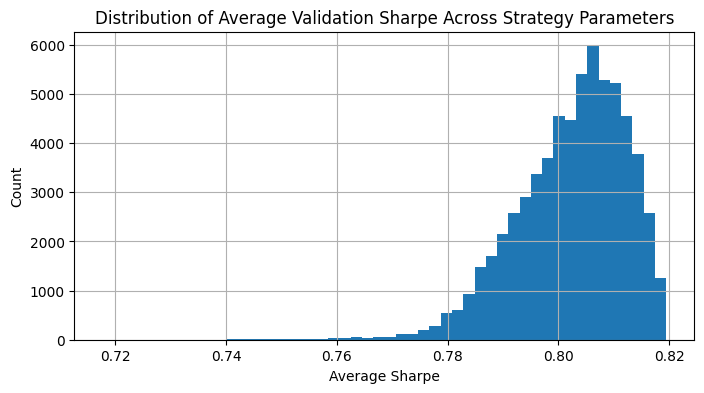

In [ ]:
# Distribution of average validation Sharpe across all strategy parameter combinations.

plt.figure(figsize=(8, 4))
plt.hist(strategy_results_df["avg_sharpe"].dropna(), bins=50)
plt.title("Distribution of Average Validation Sharpe Across Strategy Parameters")
plt.xlabel("Average Sharpe")
plt.ylabel("Count")
plt.grid(True)
plt.show()

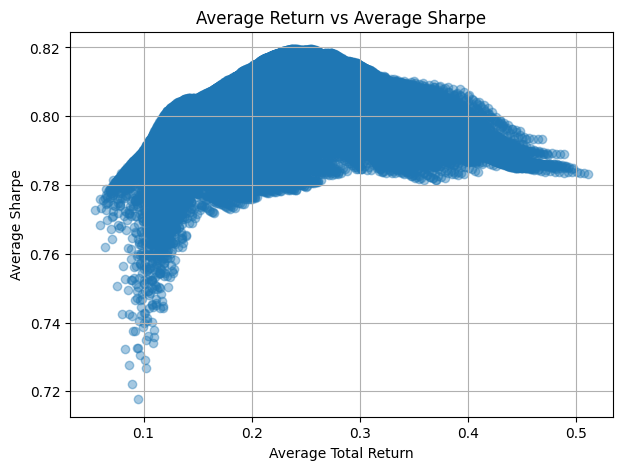

In [ ]:
# Relationship between average total return and average Sharpe across the strategy grid.
plt.figure(figsize=(7, 5))
plt.scatter(
    strategy_results_df["avg_total_return"],
    strategy_results_df["avg_sharpe"],
    alpha=0.4
)
plt.title("Average Return vs Average Sharpe")
plt.xlabel("Average Total Return")
plt.ylabel("Average Sharpe")
plt.grid(True)
plt.show()

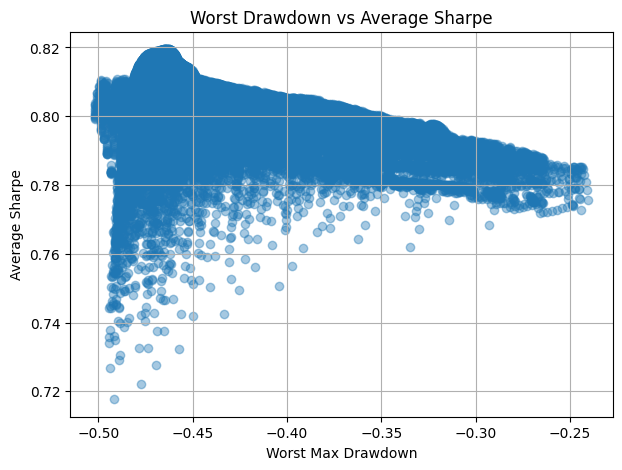

In [ ]:
# Relationship between worst drawdown and average Sharpe across the strategy grid.
plt.figure(figsize=(7, 5))
plt.scatter(
    strategy_results_df["worst_max_drawdown"],
    strategy_results_df["avg_sharpe"],
    alpha=0.4
)
plt.title("Worst Drawdown vs Average Sharpe")
plt.xlabel("Worst Max Drawdown")
plt.ylabel("Average Sharpe")
plt.grid(True)
plt.show()

The plots below show average validation Sharpe as a function of each main strategy parameter. This helps interpret which parameters were most influential during tuning.

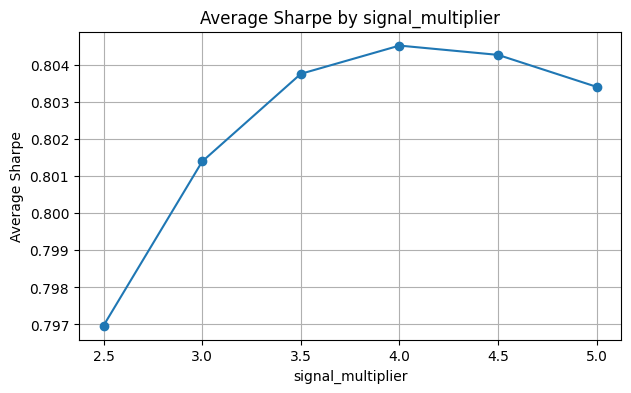

,signal_multiplier,avg_sharpe,avg_total_return,worst_max_drawdown,avg_abs_position,avg_turnover
0,2.5,0.796967,0.184248,-0.424084,0.357763,0.082312
1,3.0,0.801393,0.206349,-0.437035,0.390420,0.090105
2,3.5,0.803757,0.226435,-0.444668,0.419085,0.097022
3,4.0,0.804519,0.244933,-0.449535,0.444630,0.103231
4,4.5,0.804268,0.262242,-0.453259,0.467663,0.108864
5,5.0,0.803405,0.278687,-0.456537,0.488628,0.114018


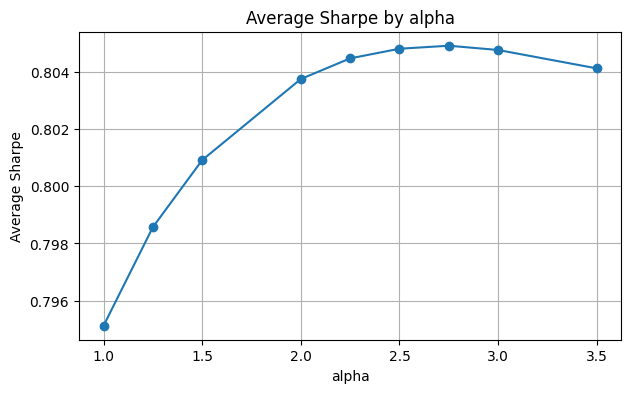

,alpha,avg_sharpe,avg_total_return,worst_max_drawdown,avg_abs_position,avg_turnover
0,1.00,0.795119,0.196150,-0.381516,0.345653,0.085413
1,1.25,0.798570,0.206197,-0.412885,0.370126,0.089287
2,1.50,0.800916,0.215104,-0.433975,0.390778,0.092661
3,2.00,0.803753,0.230697,-0.454199,0.424475,0.098429
4,2.25,0.804476,0.237667,-0.458411,0.438673,0.100937
5,2.50,0.804814,0.244212,-0.461052,0.451557,0.103236
6,2.75,0.804919,0.250426,-0.463001,0.463341,0.105348
7,3.00,0.804769,0.256350,-0.464676,0.474183,0.107290
8,3.50,0.804126,0.267537,-0.467961,0.493497,0.110728


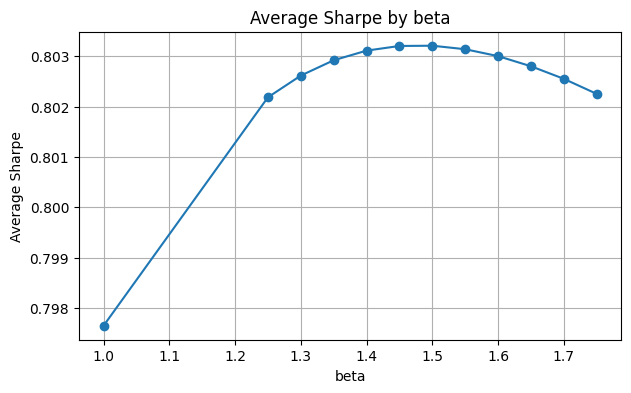

,beta,avg_sharpe,avg_total_return,worst_max_drawdown,avg_abs_position,avg_turnover
0,1.00,0.797652,0.205991,-0.449137,0.403417,0.090344
1,1.25,0.802183,0.222436,-0.446006,0.417884,0.095601
2,1.30,0.802614,0.225438,-0.445443,0.420545,0.096563
3,1.35,0.802918,0.228356,-0.444919,0.423138,0.097499
4,1.40,0.803109,0.231196,-0.444449,0.425666,0.098412
5,1.45,0.803201,0.233963,-0.444008,0.428134,0.099302
6,1.50,0.803206,0.236662,-0.443598,0.430544,0.100171
7,1.55,0.803136,0.239298,-0.443212,0.432900,0.101019
8,1.60,0.802999,0.241876,-0.442848,0.435203,0.101849
9,1.65,0.802798,0.244399,-0.442508,0.437457,0.102660


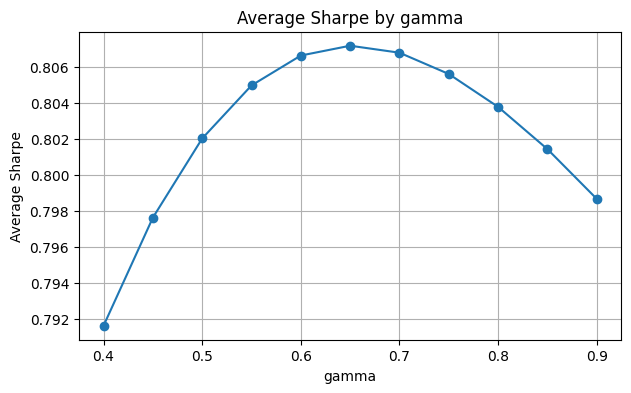

,gamma,avg_sharpe,avg_total_return,worst_max_drawdown,avg_abs_position,avg_turnover
0,0.40,0.791624,0.308971,-0.430311,0.509152,0.120022
1,0.45,0.797623,0.289575,-0.434949,0.488552,0.114996
2,0.50,0.802016,0.271978,-0.438676,0.469712,0.110303
3,0.55,0.804960,0.255961,-0.441724,0.452461,0.105921
4,0.60,0.806619,0.241347,-0.444246,0.436645,0.101829
5,0.65,0.807163,0.227990,-0.446248,0.422119,0.098003
6,0.70,0.806775,0.215784,-0.447769,0.408757,0.094427
7,0.75,0.805595,0.204607,-0.449072,0.396444,0.091085
8,0.80,0.803768,0.194376,-0.450141,0.385080,0.087956
9,0.85,0.801424,0.184996,-0.451041,0.374575,0.085025


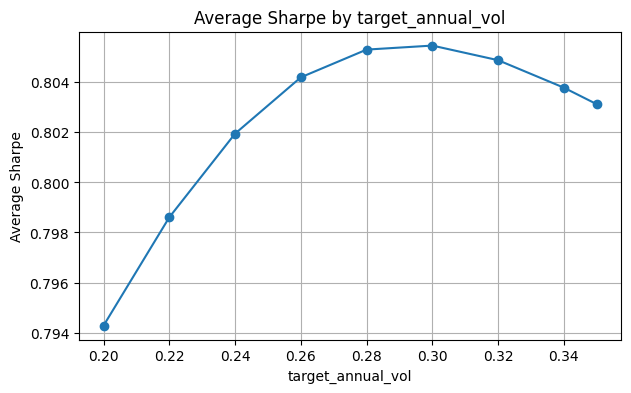

,target_annual_vol,avg_sharpe,avg_total_return,worst_max_drawdown,avg_abs_position,avg_turnover
0,0.20,0.794295,0.167632,-0.412350,0.334552,0.076884
1,0.22,0.798606,0.185127,-0.427048,0.361156,0.083175
2,0.24,0.801935,0.202406,-0.437521,0.386358,0.089179
3,0.26,0.804176,0.219347,-0.444742,0.410243,0.094906
4,0.28,0.805280,0.235848,-0.449588,0.432897,0.100362
5,0.30,0.805440,0.251955,-0.452980,0.454400,0.105562
6,0.32,0.804858,0.267729,-0.455717,0.474827,0.110516
7,0.34,0.803765,0.283279,-0.458222,0.494249,0.115235
8,0.35,0.803107,0.291018,-0.459509,0.503601,0.117509


In [81]:
params_to_check = [
    "signal_multiplier",
    # "long_threshold",
    # "short_threshold",
    "alpha",
    "beta",
    "gamma",
    "target_annual_vol"
]

for param in params_to_check:
    summary = strategy_results_df.groupby(param).agg({
        "avg_sharpe": "mean",
        "avg_total_return": "mean",
        "worst_max_drawdown": "mean",
        "avg_abs_position": "mean",
        "avg_turnover": "mean"
    }).reset_index()

    plt.figure(figsize=(7, 4))
    plt.plot(summary[param], summary["avg_sharpe"], marker="o")
    plt.title(f"Average Sharpe by {param}")
    plt.xlabel(param)
    plt.ylabel("Average Sharpe")
    plt.grid(True)
    plt.show()

    display(summary)

The bar chart below compares validation Sharpe across model/version combinations after applying the selected global strategy parameters.

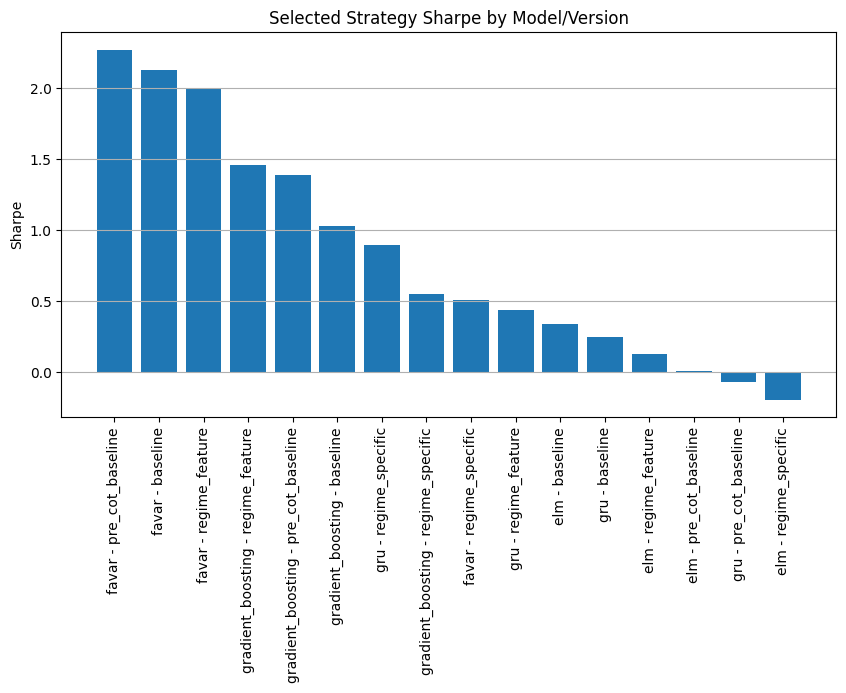

In [82]:
plt.figure(figsize=(10, 5))
plt.bar(
    selected_strategy_model_results_df["model"] + " - " + selected_strategy_model_results_df["version"],
    selected_strategy_model_results_df["Sharpe"]
)
plt.xticks(rotation=90)
plt.title("Selected Strategy Sharpe by Model/Version")
plt.ylabel("Sharpe")
plt.grid(True, axis="y")
plt.show()

The histogram below shows the average absolute position across the strategy grid. This checks whether the tuning process favored strategies that were nearly always flat or strategies that took meaningful exposure.

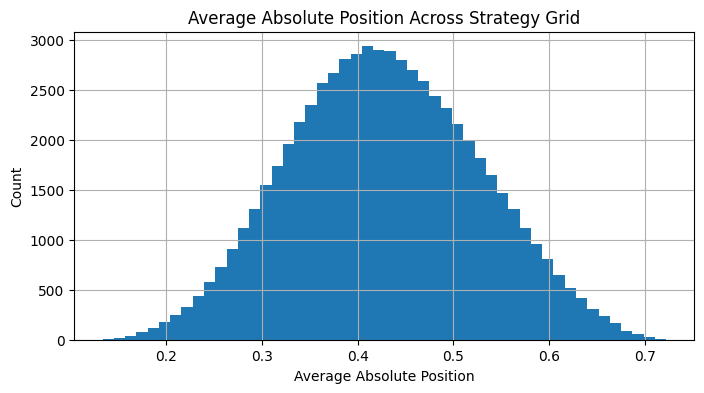

In [83]:
plt.figure(figsize=(8, 4))
plt.hist(strategy_results_df["avg_abs_position"].dropna(), bins=50)
plt.title("Average Absolute Position Across Strategy Grid")
plt.xlabel("Average Absolute Position")
plt.ylabel("Count")
plt.grid(True)
plt.show()

## 13. Inspect the Top Strategy Parameter Sets

The table below lists the highest-ranked strategy parameter combinations by average validation Sharpe. This is useful for checking whether the selected parameters are part of a broader high-performing region of the grid.

In [84]:
strategy_results_df.sort_values(
    by="avg_sharpe",
    ascending=False
)[[
    "signal_multiplier",
    "long_threshold",
    "short_threshold",
    "alpha",
    "beta",
    "gamma",
    "target_annual_vol",
    "avg_sharpe",
    "avg_total_return",
    "worst_max_drawdown",
    "avg_abs_position",
    "avg_turnover"
]].head(20)

,signal_multiplier,long_threshold,short_threshold,alpha,beta,gamma,target_annual_vol,avg_sharpe,avg_total_return,worst_max_drawdown,avg_abs_position,avg_turnover
54400,3.5,0.5,0.5,3.00,1.55,0.70,0.28,0.819483,0.239285,-0.464235,0.456984,0.103453
37169,3.0,0.5,0.5,2.50,1.30,0.70,0.35,0.819466,0.237125,-0.464959,0.453778,0.102701
37763,3.0,0.5,0.5,2.50,1.35,0.70,0.35,0.819460,0.240074,-0.464166,0.456577,0.103716
54994,3.5,0.5,0.5,3.00,1.60,0.70,0.28,0.819458,0.241779,-0.463564,0.459342,0.104310
53151,3.0,0.5,0.5,3.00,1.45,0.65,0.32,0.819457,0.254484,-0.462517,0.475281,0.107833
54386,2.5,0.5,0.5,3.00,1.55,0.70,0.35,0.819454,0.236621,-0.465092,0.453303,0.102531
63263,4.0,0.5,0.5,3.50,1.70,0.65,0.24,0.819450,0.254757,-0.462462,0.475490,0.107922
54980,2.5,0.5,0.5,3.00,1.60,0.70,0.35,0.819441,0.239074,-0.464429,0.455654,0.103381
37176,3.5,0.5,0.5,2.50,1.30,0.70,0.32,0.819437,0.241034,-0.463773,0.459225,0.104073
44851,4.0,0.5,0.5,2.75,1.35,0.65,0.28,0.819427,0.254976,-0.462465,0.475456,0.107992


## 14. Plot Tuned Strategy Growth for Individual Prediction Files

This helper applies the selected strategy parameters to a single validation prediction file and plots cumulative strategy growth against buy-and-hold. It is used below to inspect individual model/version performance visually.

In [85]:
def plot_tuned_strategy_growth_for_file(
    prediction_file,
    final_strategy_params,
    strategy_label=None,
    title=None
):
    preds = pd.read_csv(prediction_file)
    preds["Date"] = pd.to_datetime(preds["Date"])

    strategy_df = apply_probability_vol_strategy_tuned(
        preds,
        **final_strategy_params
    )

    plot_df = strategy_df.dropna(subset=["net_strategy_return"]).copy()

    plot_df["cum_strategy"] = (1 + plot_df["net_strategy_return"]).cumprod()
    plot_df["cum_buy_hold"] = (1 + plot_df["buy_hold_return"]).cumprod()

    if strategy_label is None:
        model = preds["model"].iloc[0] if "model" in preds.columns else "model"
        version = preds["version"].iloc[0] if "version" in preds.columns else "version"
        strategy_label = f"{model} - {version}"

    if title is None:
        title = f"Validation Cumulative Growth: {strategy_label} vs Buy & Hold"

    plt.figure(figsize=(12, 5))
    plt.plot(plot_df["Date"], plot_df["cum_strategy"], label=strategy_label)
    plt.plot(plot_df["Date"], plot_df["cum_buy_hold"], label="Buy & Hold")
    plt.legend()
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.grid(True)
    plt.show()

    return strategy_df

The plot below shows the tuned validation strategy for the FAVAR baseline model. This was one of the model versions emphasized in the paper because it illustrates how probability forecasts translate into trading performance.

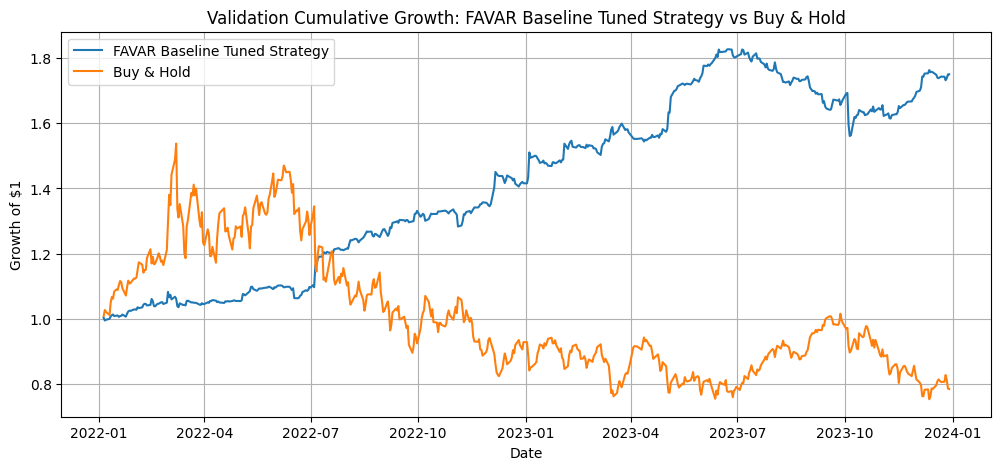

In [86]:
favar_val_strategy_tuned = plot_tuned_strategy_growth_for_file(
    "results/predictions/favar_baseline_val_predictions.csv",
    final_strategy_params,
    strategy_label="FAVAR Baseline Tuned Strategy",
    title="Validation Cumulative Growth: FAVAR Baseline Tuned Strategy vs Buy & Hold"
)

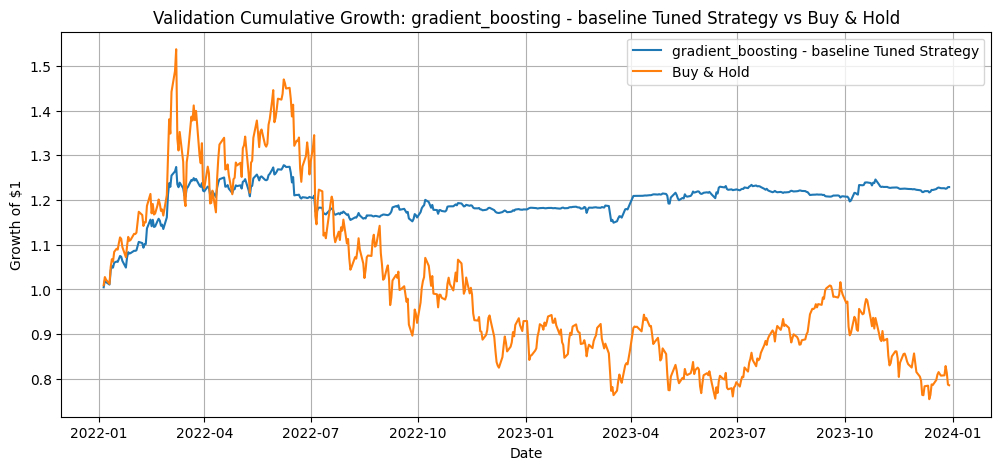

In [87]:
best_row = selected_strategy_model_results_df.iloc[5]
best_model = best_row["model"]
best_version = best_row["version"]

matching_files = [
    df["source_file"].iloc[0]
    for df in val_pred_dfs
    if df["model"].iloc[0] == best_model and df["version"].iloc[0] == best_version
]

best_file = matching_files[0]

best_strategy_df = plot_tuned_strategy_growth_for_file(
    best_file,
    final_strategy_params,
    strategy_label=f"{best_model} - {best_version} Tuned Strategy"
)

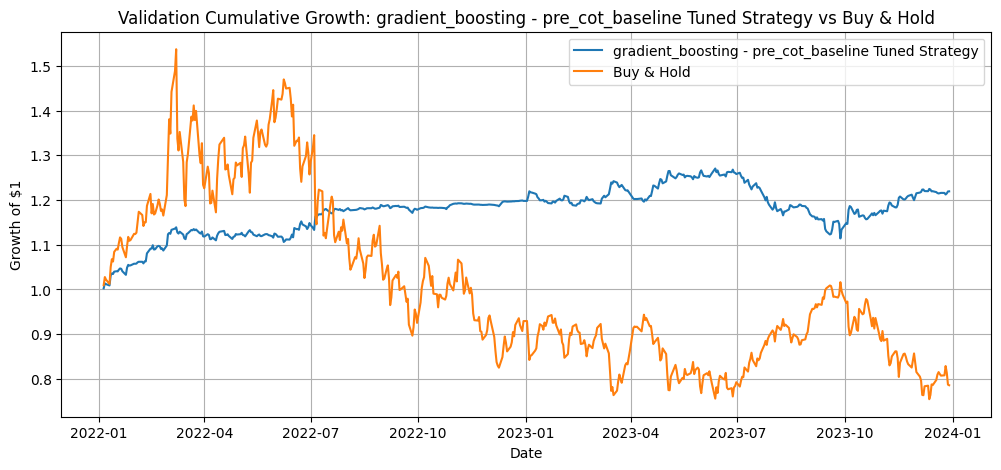

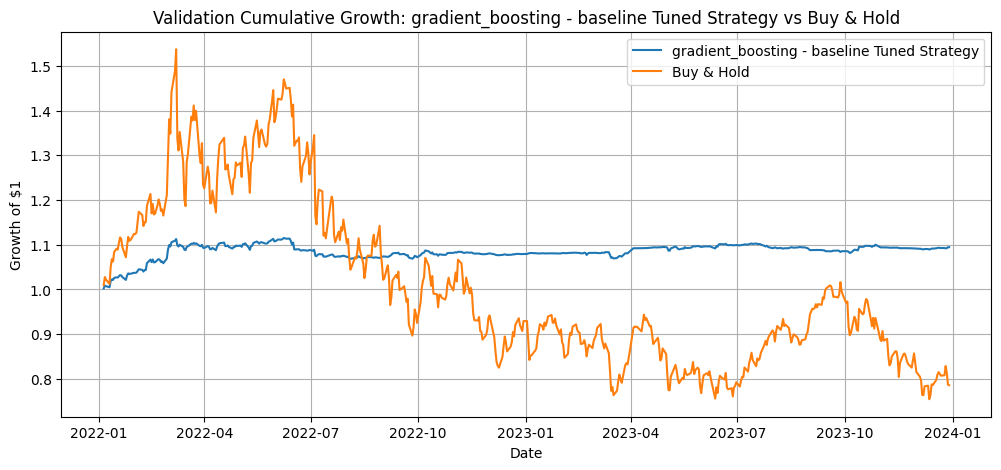

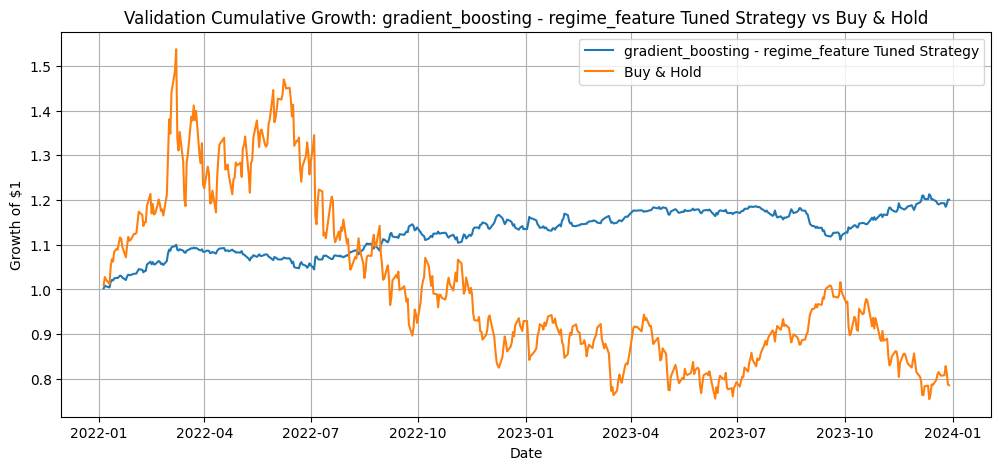

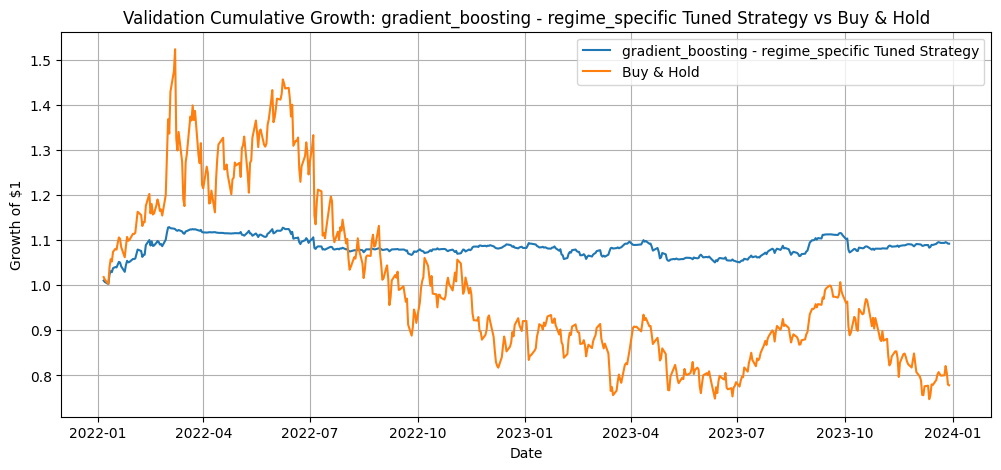

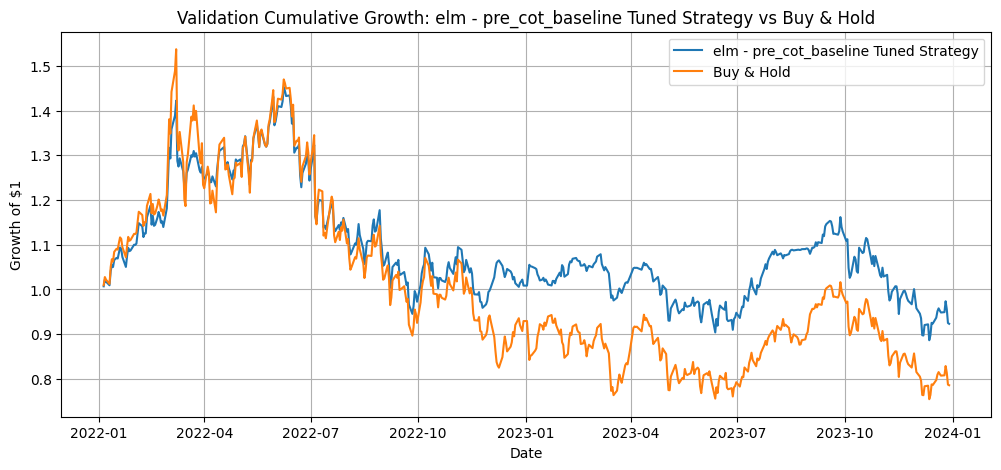

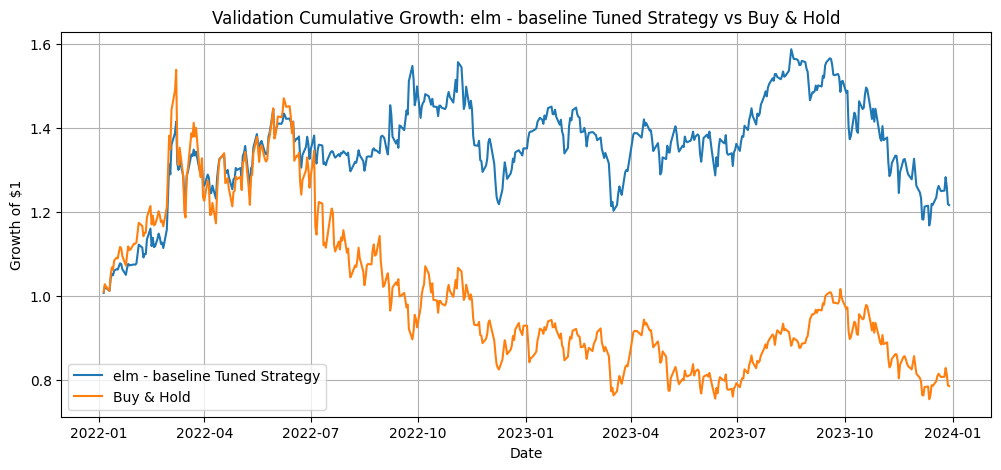

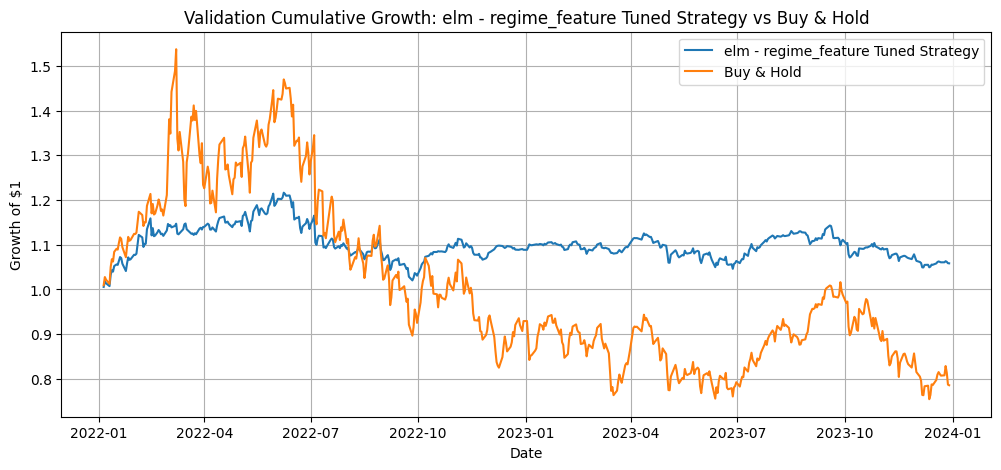

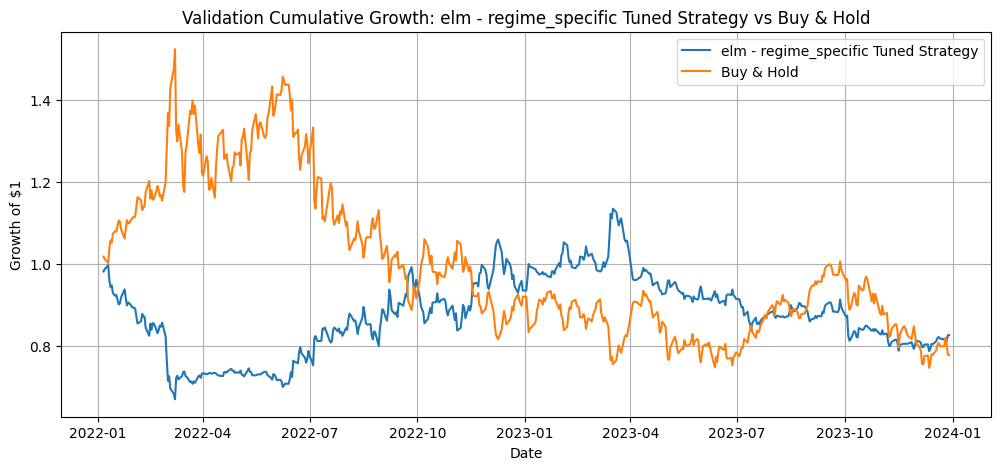

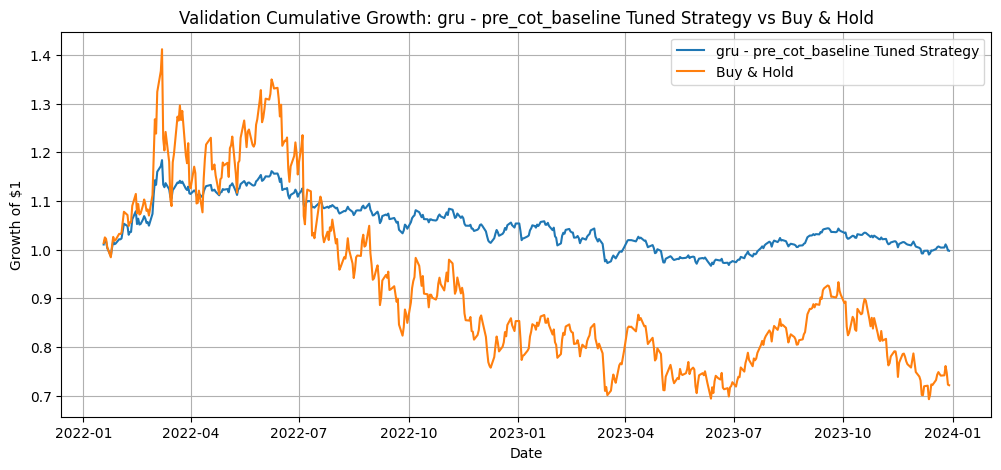

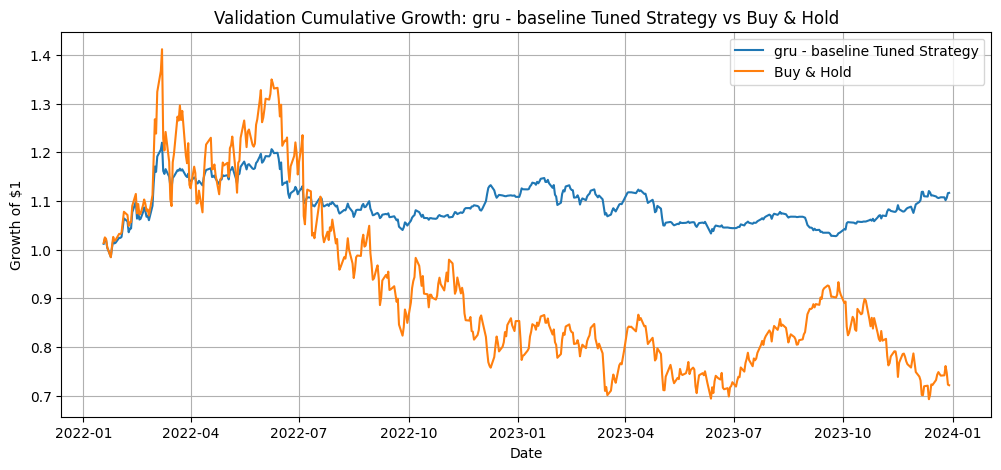

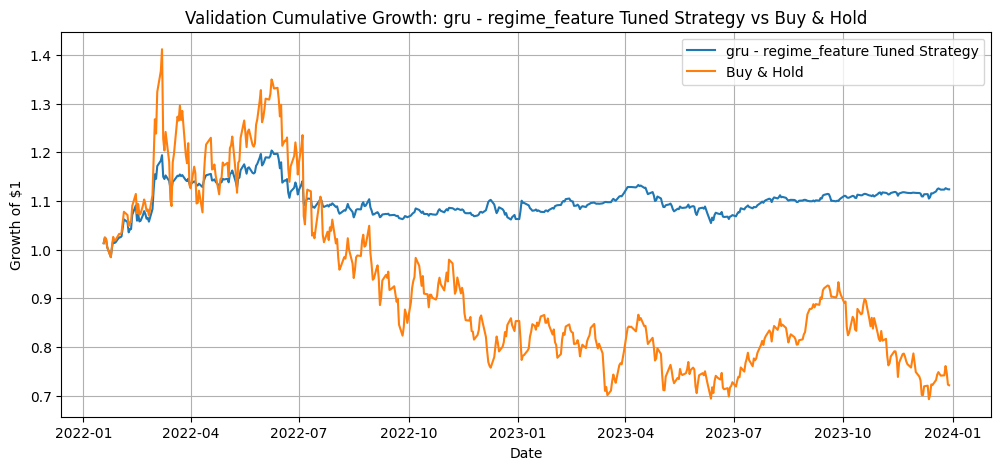

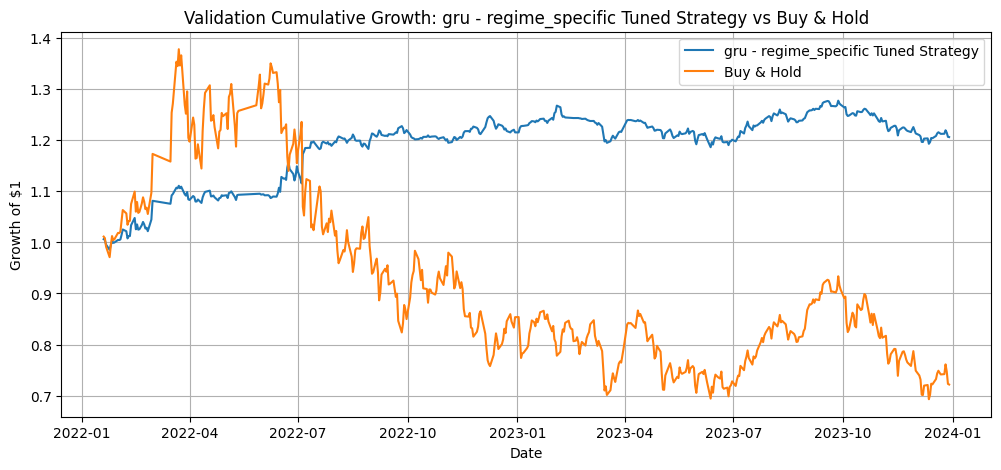

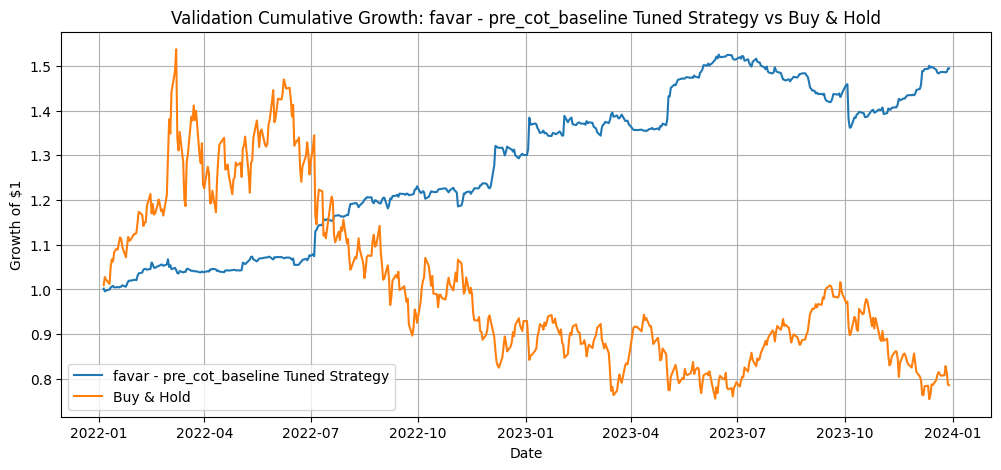

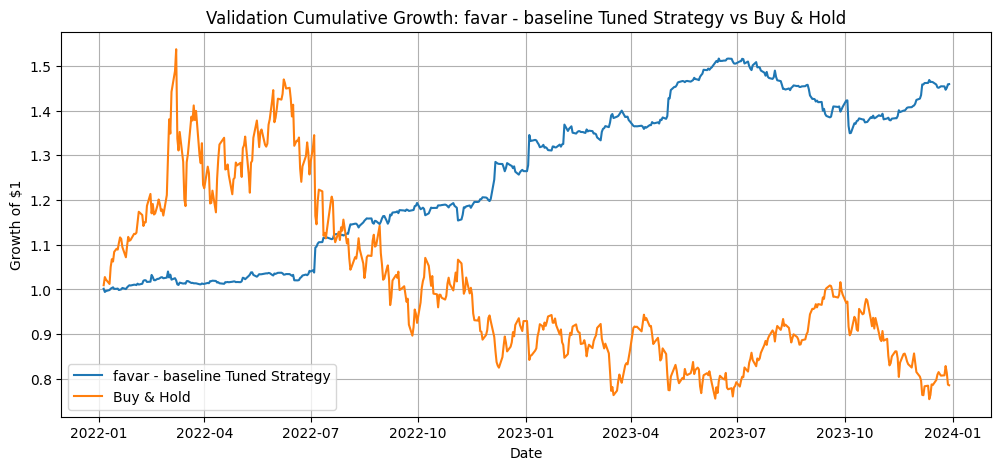

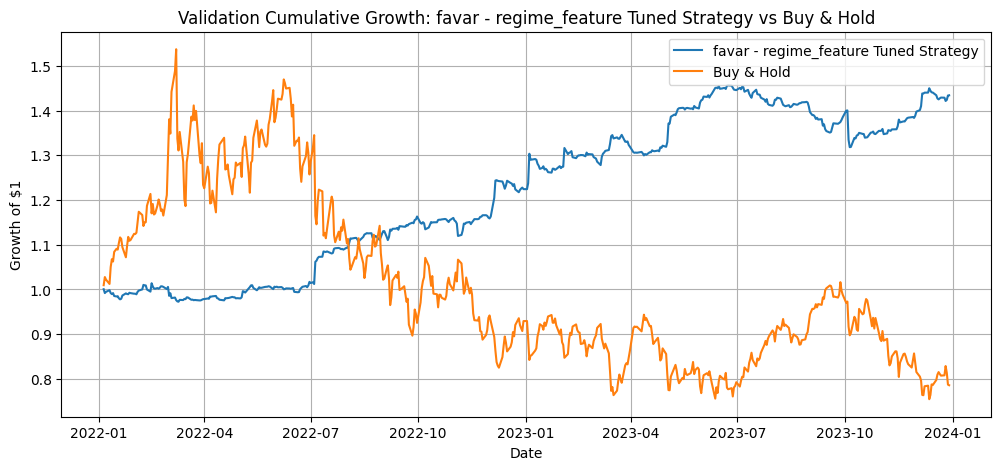

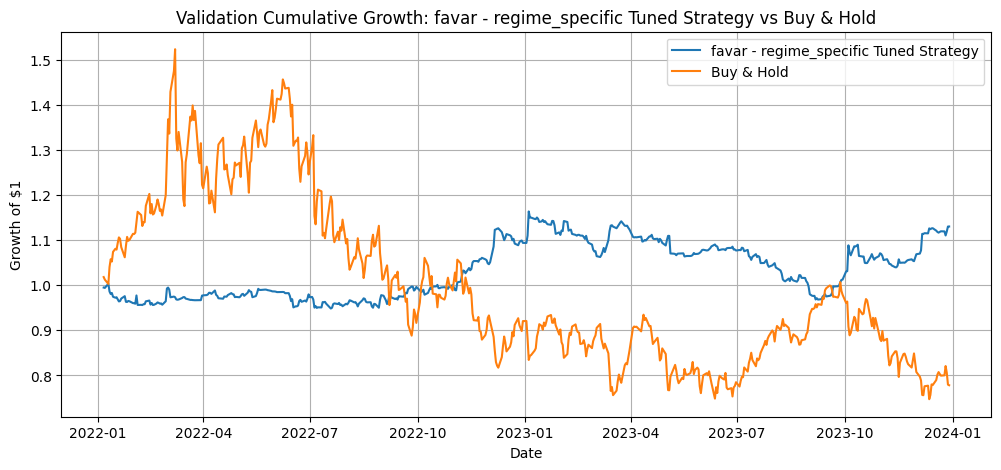

In [30]:
for preds in val_pred_dfs:
    file = preds["source_file"].iloc[0]
    model = preds["model"].iloc[0]
    version = preds["version"].iloc[0]

    plot_tuned_strategy_growth_for_file(
        file,
        final_strategy_params,
        strategy_label=f"{model} - {version} Tuned Strategy"
    )